In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch


In [2]:
path = "/data/mattkiim/eval_rgb.h5"
# path = "/data/mattkiim/eval_rgb.h5"


with h5py.File(path, "r") as f:
    failure = 0
    for trajectory in f.keys():
        group = f[trajectory]
        ir = f[trajectory]['camera_2']
        hot_inner = f[trajectory]['hot_inner']
        
        for t in range(hot_inner.shape[0]):
            frame = hot_inner[t]
            heat_avg = np.mean(frame) if frame.size > 0 else 0.0
            
            if heat_avg > 0.13:
                failure += 1
                break

        
print(failure)

10


trajectory_1
(12055,)
trajectory_1: worst=0.5106 at t=0
trajectory_10
(12271,)
trajectory_10: worst=0.6717 at t=0
trajectory_11
(12271,)
trajectory_11: worst=0.5559 at t=0
trajectory_12
(10964,)
trajectory_12: worst=0.3060 at t=0
trajectory_13
(12271,)
trajectory_13: worst=0.6146 at t=0
trajectory_14
(7576,)
trajectory_14: worst=0.5044 at t=0
trajectory_15
(12271,)
trajectory_15: worst=0.4572 at t=0
trajectory_16
(9238,)
trajectory_16: worst=0.2411 at t=0
trajectory_17
(12271,)
trajectory_17: worst=0.5209 at t=0
trajectory_18
(11326,)
trajectory_18: worst=0.6792 at t=0
trajectory_19
(4965,)
trajectory_19: worst=0.1619 at t=0
trajectory_2
(4174,)
trajectory_2: worst=0.1189 at t=0
trajectory_20
(11161,)
trajectory_20: worst=0.6550 at t=0
trajectory_21
(12271,)
trajectory_21: worst=0.5424 at t=0
trajectory_3
(9800,)
trajectory_3: worst=0.2045 at t=0
trajectory_4
(12016,)
trajectory_4: worst=0.4279 at t=0
trajectory_5
(12078,)
trajectory_5: worst=0.5291 at t=0
trajectory_6
(11156,)
traject

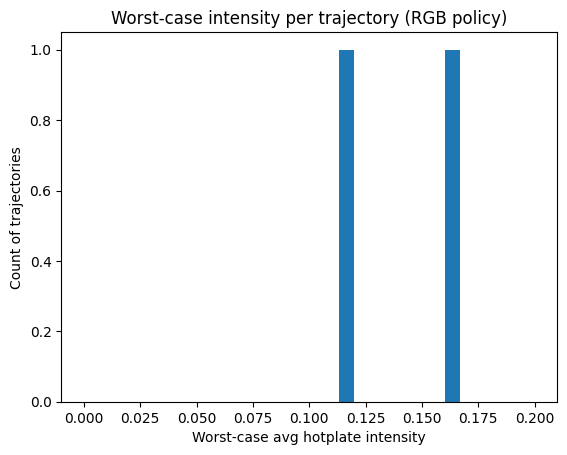

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "/data/mattkiim/eval_rgb_v2.h5"

worst_vals = []

with h5py.File(path, "r") as f:
    for traj in f.keys():
        print(traj)
        hot_inner = f[traj]['hot_inner']
        hot_inner_frame = hot_inner[t]
        hot_inner_frame = hot_inner_frame[hot_inner_frame > 0]
        # mean value per frame
        frame_means = [np.mean(hot_inner_frame)]
        
        # worst case for this trajectory
        worst_val = max(frame_means)
        worst_vals.append(worst_val)
        print(f"{traj}: worst={worst_val:.4f} at t={np.argmax(frame_means)}")

# make histogram
plt.hist(worst_vals, bins=30, range=(0.0, 1.0))
plt.xlabel("Worst-case avg hotplate intensity")
plt.ylabel("Count of trajectories")
plt.title("Worst-case intensity per trajectory (RGB policy)")
plt.show()


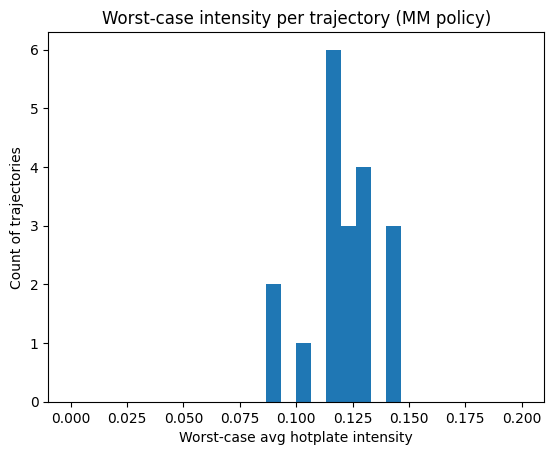

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "/data/mattkiim/eval_multimodal_v2.h5"

worst_vals = []

with h5py.File(path, "r") as f:
    for traj in f.keys():
        hot_inner = f[traj]['hot_inner']
        
        # mean value per frame
        frame_means = [np.mean(hot_inner[t]) for t in range(hot_inner.shape[0])]
        
        # worst case for this trajectory
        worst_val = max(frame_means)
        worst_vals.append(worst_val)
        # print(f"{traj}: worst={worst_val:.4f} at t={np.argmax(frame_means)}")

# make histogram
plt.hist(worst_vals, bins=30, range=(0.0, 0.2))
plt.xlabel("Worst-case avg hotplate intensity")
plt.ylabel("Count of trajectories")
plt.title("Worst-case intensity per trajectory (MM policy)")
plt.show()


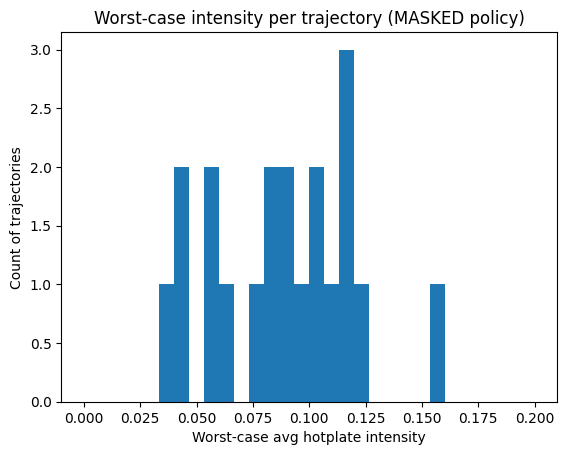

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "/data/mattkiim/eval_masked_v2.h5"

worst_vals = []

with h5py.File(path, "r") as f:
    for traj in f.keys():
        hot_inner = f[traj]['hot_inner']
        
        # mean value per frame
        frame_means = [np.mean(hot_inner[t]) for t in range(hot_inner.shape[0])]
        
        # worst case for this trajectory
        worst_val = max(frame_means)
        worst_vals.append(worst_val)
        # print(f"{traj}: worst={worst_val:.4f} at t={np.argmax(frame_means)}")

# make histogram
plt.hist(worst_vals, bins=30, range=(0.0, 0.2))
plt.xlabel("Worst-case avg hotplate intensity")
plt.ylabel("Count of trajectories")
plt.title("Worst-case intensity per trajectory (MASKED policy)")
plt.show()


In [ ]:
from scipy.spatial.transform import Rotation as R

def eef_pose_to_state(T, gripper):

    # Extract translation
    x, y, z = T[:3, 3]

    # Extract rotation matrix and convert to quaternion
    rotation_matrix = T[:3, :3]
    quat = R.from_matrix(rotation_matrix).as_quat()  # Returns [qx, qy, qz, qw]

    # Concatenate into final state
    eef_state = np.concatenate(([x, y, z], quat, [gripper]))
    return eef_state

In [ ]:
IMG_SIZE = 224  # match training
SAFE_SCALE = 0.15  # normalized-space scale; adjust as desired

def normalize_acs(acs, device='cuda:1'):
    max_ac = torch.tensor([0.10543401, 0.00693101, 1., 0.00348351 ,0.04336035, 0.00416869, 1.]).to(device)
    min_ac = torch.tensor([-0.07480399, -0.00952092, -0.80855778, -0.00182587, -0.03781896, -0.00121621,
 -1.]).to(device)
    
    acs = (acs - min_ac) / (max_ac - min_ac)
    acs = (acs*2) - 1
    return acs

def unnormalize_acs(acs, device='cuda:0'):
    max_ac = torch.tensor([0.10543401, 0.00693101, 1., 0.00348351, 0.04336035, 0.00416869, 1.]).to(device)
    min_ac = torch.tensor([-0.07480399, -0.00952092, -0.80855778, -0.00182587, -0.03781896, -0.00121621, -1.]).to(device)
    acs = (acs + 1) / 2.0
    acs = acs * (max_ac - min_ac) + min_ac
    return acs

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "/data/mattkiim/eval_masked.h5"

worst_vals = []

with h5py.File(path, "r") as f:
    for traj in f.keys():
        cam0 = torch.tensor(f[traj]['camera_0'][:])
        cam2 = torch.tensor(f[traj]['camera_2'][:])
        arm_states  = torch.tensor(f[traj]['ee_states'][:])
        grip_states = torch.tensor(f[traj]['gripper_states'][:])
        actions  = torch.tensor(f[traj]["actions"][:])
        
        for t in range(T):
            
        
            norm_ac = normalize_acs(torch.tensor([act_env]).to(device), device=device)
            
        # mean value per frame
        frame_means = [np.mean(hot_inner[t]) for t in range(hot_inner.shape[0])]
        
        # worst case for this trajectory
        worst_val = max(frame_means)
        worst_vals.append(worst_val)
        # print(f"{traj}: worst={worst_val:.4f} at t={np.argmax(frame_means)}")

# make histogram
plt.hist(worst_vals, bins=30, range=(0.0, 0.2))
plt.xlabel("Worst-case avg hotplate intensity")
plt.ylabel("Count of trajectories")
plt.title("Worst-case intensity per trajectory (MASKED policy)")
plt.show()
